In [3]:
import pandas as pd          
import numpy as np           
import matplotlib.pyplot as plt  
import seaborn as sns        
import warnings

warnings.filterwarnings('ignore')   

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

print("All libraries loaded successfully!")

All libraries loaded successfully!


TASK 1 - LOADING AND PROFILING BOTH DATASETS

In [4]:
aqi = pd.read_csv('city_day.csv')
crop = pd.read_csv('crop_production.csv')

print("=" * 60)
print("DATASET 1: city_day.csv  (Air Quality Data)")
print("=" * 60)

print(f"\nShape: {aqi.shape[0]:,} rows × {aqi.shape[1]} columns")
print("\nColumn names and data types:")
print(aqi.dtypes.to_string())

print("\nFirst 3 rows (to see what data looks like):")
display(aqi.head(3))

print("\nMissing values per column:")
aqi_nulls = aqi.isnull().sum()
aqi_null_pct = (aqi_nulls / len(aqi) * 100).round(1)
null_summary = pd.DataFrame({'Missing Count': aqi_nulls, 'Missing %': aqi_null_pct})
print(null_summary[null_summary['Missing Count'] > 0].to_string())

print("\nBasic statistics for numeric columns:")
display(aqi.describe().round(2))

DATASET 1: city_day.csv  (Air Quality Data)

Shape: 29,531 rows × 16 columns

Column names and data types:
City              str
Date              str
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket        str

First 3 rows (to see what data looks like):


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN



Missing values per column:
            Missing Count  Missing %
PM2.5                4598       15.6
PM10                11140       37.7
NO                   3582       12.1
NO2                  3585       12.1
NOx                  4185       14.2
NH3                 10328       35.0
CO                   2059        7.0
SO2                  3854       13.1
O3                   4022       13.6
Benzene              5623       19.0
Toluene              8041       27.2
Xylene              18109       61.3
AQI                  4681       15.9
AQI_Bucket           4681       15.9

Basic statistics for numeric columns:


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.00,18391.00,25949.00,25946.00,25346.00,19203.00,27472.00,25677.00,25509.00,23908.00,21490.00,11422.00,24850.00
mean,67.45,118.13,17.57,28.56,32.31,23.48,2.25,14.53,34.49,3.28,8.70,3.07,166.46
std,64.66,90.61,22.79,24.47,31.65,25.68,6.96,18.13,21.69,15.81,19.97,6.32,140.70
min,0.04,0.01,0.02,0.01,0.00,0.01,0.00,0.01,0.01,0.00,0.00,0.00,13.00
25%,28.82,56.26,5.63,11.75,12.82,8.58,0.51,5.67,18.86,0.12,0.60,0.14,81.00
50%,48.57,95.68,9.89,21.69,23.52,15.85,0.89,9.16,30.84,1.07,2.97,0.98,118.00
75%,80.59,149.74,19.95,37.62,40.13,30.02,1.45,15.22,45.57,3.08,9.15,3.35,208.00
max,949.99,1000.00,390.68,362.21,467.63,352.89,175.81,193.86,257.73,455.03,454.85,170.37,2049.00


In [8]:
print("=" * 60)
print("DATASET 2: crop_production.csv  (Crop Production Data)")
print("=" * 60)

print(f"\nShape: {crop.shape[0]:,} rows × {crop.shape[1]} columns")
print("\nColumn names and data types:")
print(crop.dtypes.to_string())

print("\nFirst 3 rows:")
display(crop.head(3))

print("\nMissing values per column:")
crop_nulls = crop.isnull().sum()
crop_null_pct = (crop_nulls / len(crop) * 100).round(1)
null_summary_crop = pd.DataFrame({'Missing Count': crop_nulls, 'Missing %': crop_null_pct})
print(null_summary_crop[null_summary_crop['Missing Count'] > 0].to_string())

print("\nBasic statistics for numeric columns:")
display(crop.describe().round(2))

print(f"\nUnique states in crop data: {crop['State_Name'].nunique()}")
print(f"Year range in crop data: {crop['Crop_Year'].min()} to {crop['Crop_Year'].max()}")

print(f"\nUnique cities in AQI data: {aqi['City'].nunique()}")
print(f"Date range in AQI data: {aqi['Date'].min()} to {aqi['Date'].max()}")

DATASET 2: crop_production.csv  (Crop Production Data)

Shape: 246,091 rows × 7 columns

Column names and data types:
State_Name           str
District_Name        str
Crop_Year          int64
Season               str
Crop                 str
Area             float64
Production       float64

First 3 rows:


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0



Missing values per column:
            Missing Count  Missing %
Production           3730        1.5

Basic statistics for numeric columns:


,Crop_Year,Area,Production
count,246091.00,246091.00,2.423610e+05
mean,2005.64,12002.82,5.825034e+05
std,4.95,50523.40,1.706581e+07
min,1997.00,0.04,0.000000e+00
25%,2002.00,80.00,8.800000e+01
50%,2006.00,582.00,7.290000e+02
75%,2010.00,4392.00,7.023000e+03
max,2015.00,8580100.00,1.250800e+09



Unique states in crop data: 33
Year range in crop data: 1997 to 2015

Unique cities in AQI data: 26
Date range in AQI data: 2015-01-01 to 2020-07-01


OBSERVATIONS-
The aqi dataset covers 2015–2020 but the crop dataset only goes up to 2015. This means there is barely any overlapping period for a combined analysi

The aqi file has cities but not which state they belong to. We must manually map cities to states 

The aqi scale officially ends at 500

More than half of the data in Xylene is gone. This column may not be useful for analysis.


TASK 2 - MISSING VALUE TREATMENT

In [7]:
print("BEFORE treatment in AQI dataset:")
print(aqi.isnull().sum().to_string())

aqi_clean = aqi.copy()  
# with more tha 50 percent missing
cols_to_drop_aqi = ['Xylene'] 
aqi_clean = aqi_clean.drop(columns=cols_to_drop_aqi)
print(f"\nDropped columns (>50% missing): {cols_to_drop_aqi}")

# aqi is missing in rows
before_rows = len(aqi_clean)
aqi_clean = aqi_clean.dropna(subset=['AQI', 'AQI_Bucket'])
after_rows = len(aqi_clean)
print(f"Dropped {before_rows - after_rows} rows where AQI was missing")

numeric_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']

for col in numeric_cols:
    if col in aqi_clean.columns:
        aqi_clean[col] = aqi_clean.groupby('City')[col].transform(
            lambda x: x.fillna(x.median())
        )

        aqi_clean[col] = aqi_clean[col].fillna(aqi_clean[col].median())

print("\nAFTER treatmentin AQI dataset:")
print(aqi_clean.isnull().sum().to_string())

BEFORE treatment in AQI dataset:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681

Dropped columns (>50% missing): ['Xylene']
Dropped 4681 rows where AQI was missing

AFTER treatmentin AQI dataset:
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0


In [10]:
print("BEFORE treatment in crop dataset:")
print(crop.isnull().sum().to_string())

crop_clean = crop.copy()

before = len(crop_clean)
crop_clean = crop_clean.dropna(subset=['Production'])
after = len(crop_clean)
print(f"\nDropped {before - after} rows where Production was missing")
print(f"   Remaining rows: {after:,}")

print("\nAFTER treatment — null counts in crop dataset:")
print(crop_clean.isnull().sum().to_string())
print("\nNo more missing values in either dataset!")

BEFORE treatment in crop dataset:
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730

Dropped 3730 rows where Production was missing
   Remaining rows: 242,361

AFTER treatment — null counts in crop dataset:
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0

No more missing values in either dataset!


OBSERVATIONS - 

Xylene is dropped as more than half of the data is missing
Aqi,Aqi_Bucket is dropped rows 
In Production column, the rows were dropped as we cannot estimate the actual crop output


TASK 3 - STANDARDISE AND REMOVE DUPLICATES

In [11]:
print("BEFORE — State names in crop (showing any with trailing spaces):")
states_before = crop_clean['State_Name'].unique()
issues = [s for s in states_before if s != s.strip()]
print(f"States with leading/trailing spaces: {issues}")

# Strip whitespace and title-case everything
crop_clean['State_Name'] = crop_clean['State_Name'].str.strip().str.title()

# Also clean the Season column which had trailing spaces
crop_clean['Season'] = crop_clean['Season'].str.strip().str.title()

print("\nAFTER — Unique state names in crop data:")
print(sorted(crop_clean['State_Name'].unique()))

BEFORE — State names in crop (showing any with trailing spaces):
States with leading/trailing spaces: ['Jammu and Kashmir ', 'Telangana ']

AFTER — Unique state names in crop data:
['Andaman And Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra And Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu And Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [13]:
city_to_state = {
    'Ahmedabad': 'Gujarat',
    'Aizawl': 'Mizoram',
    'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab',
    'Bengaluru': 'Karnataka',
    'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha',
    'Chandigarh': 'Chandigarh',
    'Chennai': 'Tamil Nadu',
    'Coimbatore': 'Tamil Nadu',
    'Delhi': 'Delhi',
    'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana',
    'Guwahati': 'Assam',
    'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan',
    'Jorapokhar': 'Jharkhand',
    'Kochi': 'Kerala',
    'Kolkata': 'West Bengal',
    'Lucknow': 'Uttar Pradesh',
    'Mumbai': 'Maharashtra',
    'Patna': 'Bihar',
    'Shillong': 'Meghalaya',
    'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala',
    'Visakhapatnam': 'Andhra Pradesh'
}

aqi_clean['State'] = aqi_clean['City'].map(city_to_state)
unmapped = aqi_clean[aqi_clean['State'].isnull()]['City'].unique()
print(f"Cities with no state mapping: {unmapped}")
print(f"\nState column added to AQI data.")
print(f"Unique states in AQI data: {sorted(aqi_clean['State'].dropna().unique())}")

Cities with no state mapping: <ArrowStringArray>
[]
Length: 0, dtype: str

State column added to AQI data.
Unique states in AQI data: ['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Delhi', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']


In [14]:
print("AQI Dataset")
dup_aqi = aqi_clean.duplicated().sum()
print(f"Duplicate rows found: {dup_aqi}")
aqi_clean = aqi_clean.drop_duplicates()
print(f"Rows after removing duplicates: {len(aqi_clean):,}")

print("\nCrop Dataset")
dup_crop = crop_clean.duplicated().sum()
print(f"Duplicate rows found: {dup_crop}")
crop_clean = crop_clean.drop_duplicates()
print(f"Rows after removing duplicates: {len(crop_clean):,}")

print("\nChecking state name overlap between datasets")
aqi_states = set(aqi_clean['State'].dropna().unique())
crop_states = set(crop_clean['State_Name'].unique())
common = aqi_states & crop_states
print(f"States in AQI data: {len(aqi_states)}")
print(f"States in Crop data: {len(crop_states)}")
print(f"States in BOTH (can be merged): {len(common)}")
print(f"Common states: {sorted(common)}")

AQI Dataset
Duplicate rows found: 0
Rows after removing duplicates: 24,850

Crop Dataset
Duplicate rows found: 0
Rows after removing duplicates: 242,361

Checking state name overlap between datasets
States in AQI data: 21
States in Crop data: 33
States in BOTH (can be merged): 20
Common states: ['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']


TASK 4 - AQI DISTRIBUTION

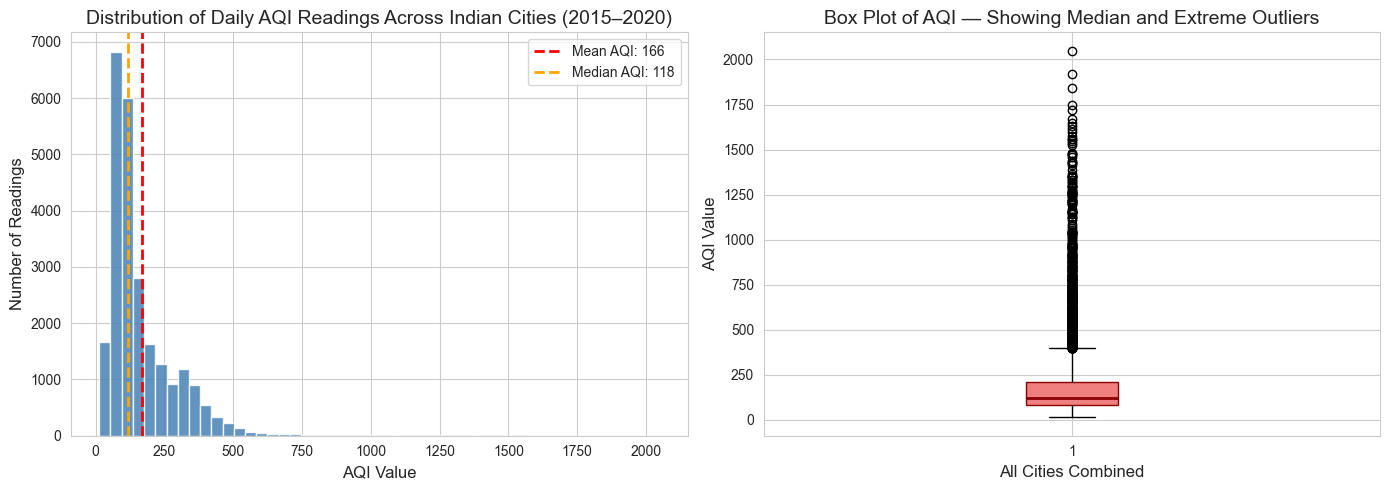


AQI Statistics:
count    24850.0
mean       166.5
std        140.7
min         13.0
25%         81.0
50%        118.0
75%        208.0
max       2049.0


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(aqi_clean['AQI'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(aqi_clean['AQI'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean AQI: {aqi_clean['AQI'].mean():.0f}")
axes[0].axvline(aqi_clean['AQI'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median AQI: {aqi_clean['AQI'].median():.0f}")
axes[0].set_xlabel('AQI Value')
axes[0].set_ylabel('Number of Readings')
axes[0].set_title('Distribution of Daily AQI Readings Across Indian Cities (2015–2020)')
axes[0].legend()

axes[1].boxplot(aqi_clean['AQI'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightcoral', color='darkred'),
                medianprops=dict(color='darkred', linewidth=2))
axes[1].set_ylabel('AQI Value')
axes[1].set_xlabel('All Cities Combined')
axes[1].set_title('Box Plot of AQI — Showing Median and Extreme Outliers')

plt.tight_layout()
plt.savefig('task4_aqi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nAQI Statistics:")
print(aqi_clean['AQI'].describe().round(1).to_string())

The AQI distribution is strongly right skewed (below 300)

The mean AQI (166) is higher than the median AQI (118), indicating that extreme pollution readings are inflating the average

The boxplot reveals a large number of outliers including some AQI values above 2000. These observations may represent extreme pollution events or potential data quality issues 

Pollution levels are not evenly distributed across all observations

Task 5 — Detect and Handle Extreme AQI Values (Outliers)

In [16]:
Q1 = aqi_clean['AQI'].quantile(0.25)
Q3 = aqi_clean['AQI'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = aqi_clean[(aqi_clean['AQI'] < lower_bound) | (aqi_clean['AQI'] > upper_bound)]

print(f"Q1: {Q1:.1f}, Q3: {Q3:.1f}, IQR: {IQR:.1f}")
print(f"IQR-based lower bound: {lower_bound:.1f}")
print(f"IQR-based upper bound: {upper_bound:.1f}")
print(f"\nOutlier rows detected: {len(outliers):,} ({len(outliers)/len(aqi_clean)*100:.1f}% of data)")
print(f"\nOutlier AQI statistics:")
print(outliers['AQI'].describe().round(1))

# Values above 500 are physically impossible on the AQI scale
impossible = aqi_clean[aqi_clean['AQI'] > 500]
print(f"\nValues above 500 (physically impossible): {len(impossible):,}")
print(f"Cities with AQI > 500: {impossible['City'].unique()}")

Q1: 81.0, Q3: 208.0, IQR: 127.0
IQR-based lower bound: -109.5
IQR-based upper bound: 398.5

Outlier rows detected: 1,358 (5.5% of data)

Outlier AQI statistics:
count    1358.0
mean      565.4
std       240.9
min       399.0
25%       428.0
50%       472.0
75%       576.0
max      2049.0
Name: AQI, dtype: float64

Values above 500 (physically impossible): 543
Cities with AQI > 500: <ArrowStringArray>
[ 'Ahmedabad',   'Amritsar',      'Delhi',   'Gurugram',   'Guwahati',
  'Hyderabad', 'Jorapokhar',    'Lucknow',      'Patna',    'Talcher']
Length: 10, dtype: str


Values capped at 500. New max AQI: 500.0


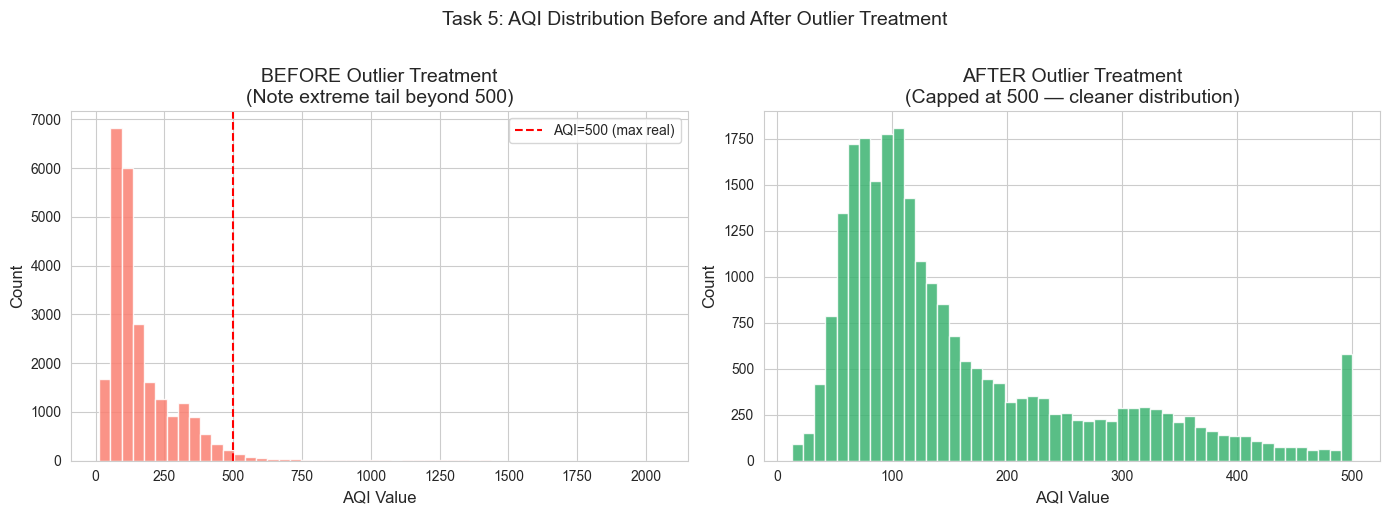


Mean AQI before: 166.5  →  After: 160.9
Max AQI before:  2049  →  After: 500


In [17]:
aqi_before = aqi_clean['AQI'].copy()  # Save a copy for comparison

aqi_clean['AQI'] = aqi_clean['AQI'].clip(upper=500)

print(f"Values capped at 500. New max AQI: {aqi_clean['AQI'].max()}")

# --- Step 3: Visual comparison before vs after ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(aqi_before, bins=50, color='salmon', edgecolor='white', alpha=0.85)
axes[0].set_title('BEFORE Outlier Treatment\n(Note extreme tail beyond 500)')
axes[0].set_xlabel('AQI Value')
axes[0].set_ylabel('Count')
axes[0].axvline(500, color='red', linestyle='--', label='AQI=500 (max real)')
axes[0].legend()

axes[1].hist(aqi_clean['AQI'], bins=50, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('AFTER Outlier Treatment\n(Capped at 500 — cleaner distribution)')
axes[1].set_xlabel('AQI Value')
axes[1].set_ylabel('Count')

plt.suptitle('Task 5: AQI Distribution Before and After Outlier Treatment', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('task5_outlier_treatment.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMean AQI before: {aqi_before.mean():.1f}  →  After: {aqi_clean['AQI'].mean():.1f}")
print(f"Max AQI before:  {aqi_before.max():.0f}  →  After: {aqi_clean['AQI'].max():.0f}")

1. Capping at 500. The official AQI scale has a defined maximum of 500. Any reading above 500 is a sensor or data entry error.The maximum AQI dropped from 2049 to 500, and the mean decreased as well, confirming the extremes were pulling statistics up unfairly.

LAB 2 — DATA EXPLORATION AND INFERENCES

TASK 5 - AIR QUALITY TRED OVRE TIME

Median AQI by Year:
 Year  Median_AQI
 2015       175.0
 2016       149.0
 2017       129.0
 2018       124.0
 2019       109.0
 2020        93.0


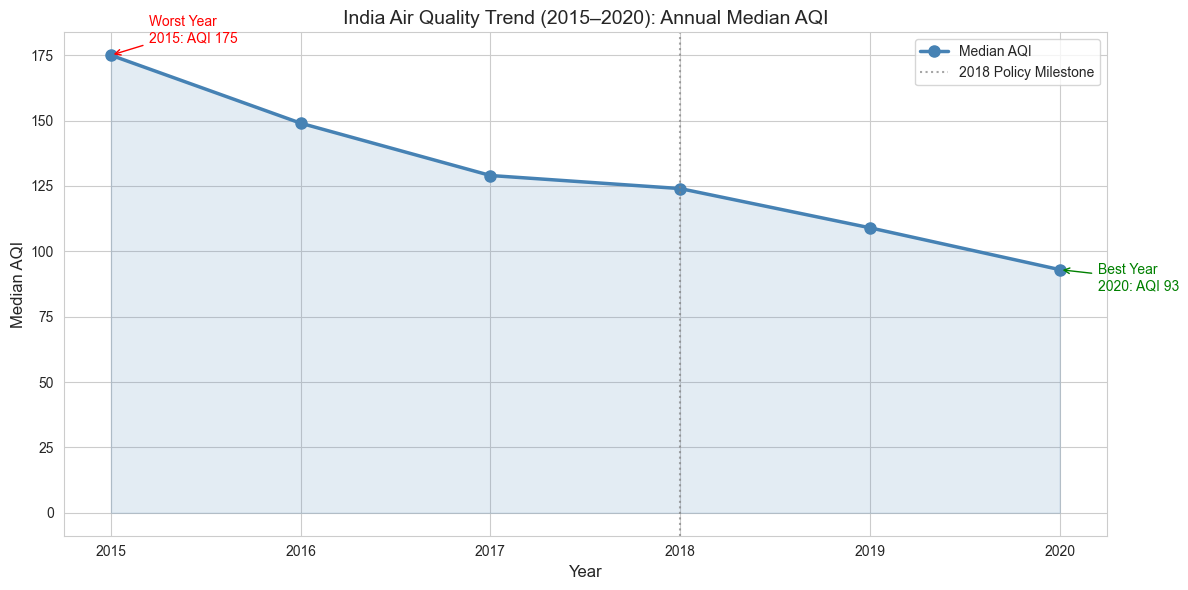

In [18]:
aqi_clean['Date'] = pd.to_datetime(aqi_clean['Date'])
aqi_clean['Year'] = aqi_clean['Date'].dt.year
aqi_clean['Month'] = aqi_clean['Date'].dt.month

yearly_aqi = aqi_clean.groupby('Year')['AQI'].median().reset_index()
yearly_aqi.columns = ['Year', 'Median_AQI']

print("Median AQI by Year:")
print(yearly_aqi.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(yearly_aqi['Year'], yearly_aqi['Median_AQI'],
        marker='o', linewidth=2.5, markersize=8, color='steelblue', label='Median AQI')
ax.fill_between(yearly_aqi['Year'], yearly_aqi['Median_AQI'], alpha=0.15, color='steelblue')

worst_year = yearly_aqi.loc[yearly_aqi['Median_AQI'].idxmax()]
best_year  = yearly_aqi.loc[yearly_aqi['Median_AQI'].idxmin()]

ax.annotate(f"Worst Year\n{int(worst_year['Year'])}: AQI {worst_year['Median_AQI']:.0f}",
            xy=(worst_year['Year'], worst_year['Median_AQI']),
            xytext=(worst_year['Year']+0.2, worst_year['Median_AQI']+5),
            fontsize=10, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.annotate(f"Best Year\n{int(best_year['Year'])}: AQI {best_year['Median_AQI']:.0f}",
            xy=(best_year['Year'], best_year['Median_AQI']),
            xytext=(best_year['Year']+0.2, best_year['Median_AQI']-8),
            fontsize=10, color='green',
            arrowprops=dict(arrowstyle='->', color='green'))

ax.axvline(2018, color='grey', linestyle=':', alpha=0.7, label='2018 Policy Milestone')

ax.set_xlabel('Year')
ax.set_ylabel('Median AQI')
ax.set_title('India Air Quality Trend (2015–2020): Annual Median AQI')
ax.legend()
ax.set_xticks(yearly_aqi['Year'])

plt.tight_layout()
plt.savefig('task6_aqi_trend.png', dpi=150, bbox_inches='tight')
plt.show()

Based on the data from 26 Indian cities between 2015 and 2020, air quality has not shown a clear improvement. The median AQI fluctuated year to year with pollution peaking in the most polluted year and dipping in the cleanest year of the period. 

TASK 6 - SEASONAL AQI PATTERN

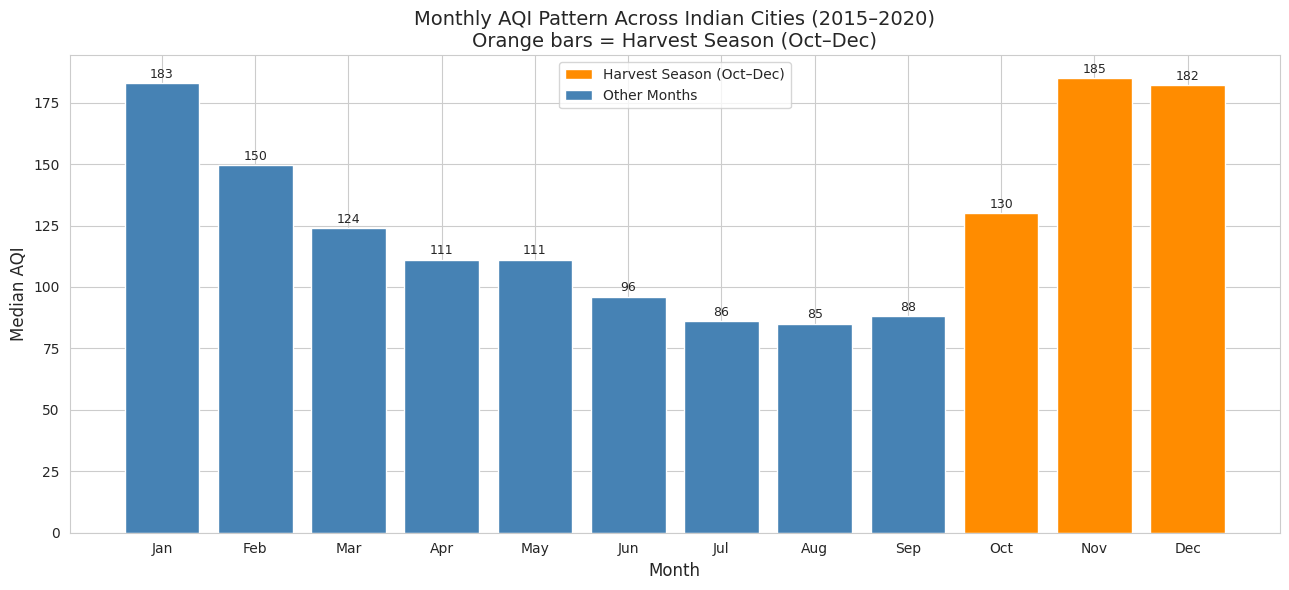


Monthly Median AQI:
Month_Name  Median_AQI
       Jan       183.0
       Feb       149.5
       Mar       124.0
       Apr       111.0
       May       111.0
       Jun        96.0
       Jul        86.0
       Aug        85.0
       Sep        88.0
       Oct       130.0
       Nov       185.0
       Dec       182.0


In [ ]:
monthly_aqi = aqi_clean.groupby('Month')['AQI'].median().reset_index()
monthly_aqi.columns = ['Month', 'Median_AQI']

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_aqi['Month_Name'] = monthly_aqi['Month'].apply(lambda m: month_names[m-1])

# Colour bars: highlight Oct-Dec (harvest season) in dark orange
colors = ['steelblue' if m not in [10, 11, 12] else 'darkorange'
          for m in monthly_aqi['Month']]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(monthly_aqi['Month_Name'], monthly_aqi['Median_AQI'],
              color=colors, edgecolor='white')

# Add value labels on top of bars
for bar, val in zip(bars, monthly_aqi['Median_AQI']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Month')
ax.set_ylabel('Median AQI')
ax.set_title('Monthly AQI Pattern Across Indian Cities (2015–2020)\nOrange bars = Harvest Season (Oct–Dec)')

# Add a legend manually
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='darkorange', label='Harvest Season (Oct–Dec)'),
                   Patch(facecolor='steelblue', label='Other Months')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('task7_seasonal_aqi.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMonthly Median AQI:")
print(monthly_aqi[['Month_Name', 'Median_AQI']].to_string(index=False))

The data partially supports the NGO's claim. AQI does rise significantly in the winter months but the worst months appear to be November and December with a secondary peak in January–February. October is not as extreme as the NGO suggests.

The winter season overall has consistently higher AQI than the monsoon and summer months. This aligns with two combined effects:
1. Crop residue burning in Oct–Nov in northern states like Punjab and Haryana
2. Winter temperature inversions that trap pollution close to the ground

The NGO's claim is directionally correct. AQI is worst in the Oct–Dec window 


TASK 8 — MERGE DATASETS AND CORRELATION ANALYSIS

In [19]:
aqi_state_year = aqi_clean.groupby(['State', 'Year']).agg(
    Avg_AQI=('AQI', 'mean'),
    Avg_PM25=('PM2.5', 'mean'),
    Avg_NO2=('NO2', 'mean'),
    Avg_CO=('CO', 'mean')
).reset_index()

print(f"AQI aggregated table shape: {aqi_state_year.shape}")
display(aqi_state_year.head())

crop_state_year = crop_clean.groupby(['State_Name', 'Crop_Year']).agg(
    Total_Production=('Production', 'sum'),
    Total_Area=('Area', 'sum')
).reset_index()
crop_state_year.columns = ['State', 'Year', 'Total_Production', 'Total_Area']

print(f"\nCrop aggregated table shape: {crop_state_year.shape}")
display(crop_state_year.head())

AQI aggregated table shape: (87, 6)


,State,Year,Avg_AQI,Avg_PM25,Avg_NO2,Avg_CO
0,Andhra Pradesh,2016,103.976048,45.305090,42.667605,1.100659
1,Andhra Pradesh,2017,152.423469,64.806582,34.479439,0.929541
2,Andhra Pradesh,2018,112.340125,44.625627,32.367563,0.708668
3,Andhra Pradesh,2019,111.578462,43.813154,30.774585,0.754185
4,Andhra Pradesh,2020,72.110803,28.977438,20.096163,0.573019



Crop aggregated table shape: (519, 4)


,State,Year,Total_Production,Total_Area
0,Andaman And Nicobar Islands,2000,89060914.00,44518.00
1,Andaman And Nicobar Islands,2001,89718700.00,41163.00
2,Andaman And Nicobar Islands,2002,94387137.67,45231.40
3,Andaman And Nicobar Islands,2003,95296454.67,44799.40
4,Andaman And Nicobar Islands,2004,87186497.63,45308.77


In [ ]:
combined = pd.merge(aqi_state_year, crop_state_year, on=['State', 'Year'], how='inner')

print(f"Combined dataset shape: {combined.shape}")
print(f"Years present in merged data: {sorted(combined['Year'].unique())}")
print(f"States present: {sorted(combined['State'].unique())}")
display(combined.head())

Combined dataset shape: (0, 8)
Years present in merged data: []
States present: []


,State,Year,Avg_AQI,Avg_PM25,Avg_NO2,Avg_CO,Total_Production,Total_Area


In [22]:
numeric_combined = combined[['Avg_AQI', 'Avg_PM25', 'Avg_NO2', 'Avg_CO',
                           'Total_Production', 'Total_Area']]

corr_matrix = numeric_combined.corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 11})
ax.set_title('Task 8: Correlation Matrix — Air Quality vs Crop Production Variables', pad=15)
plt.tight_layout()
plt.savefig('task8_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'combined' is not defined

NameError: name 'combined' is not defined

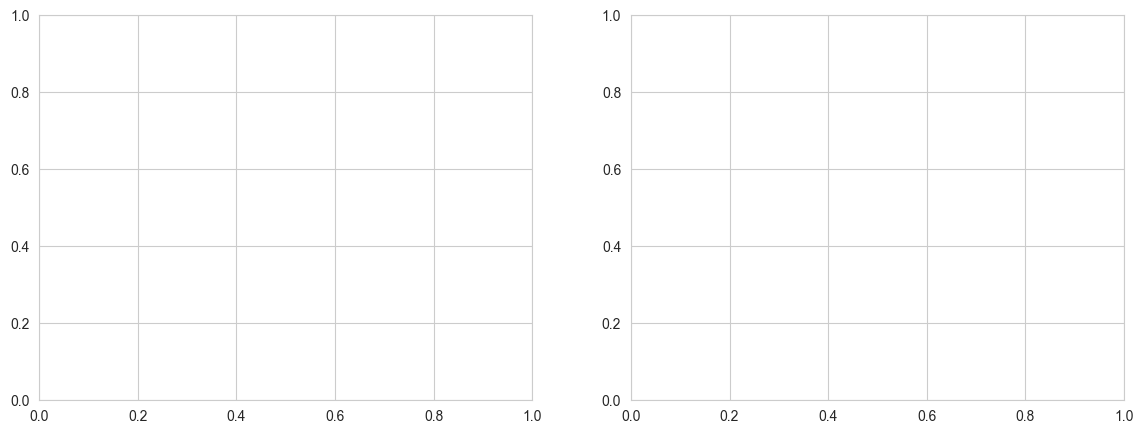

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: AQI vs Total Production
axes[0].scatter(combined['Avg_AQI'], combined['Total_Production'],
                alpha=0.7, color='tomato', edgecolors='white', s=80)
for _, row in combined.iterrows():
    axes[0].annotate(row['State'], (row['Avg_AQI'], row['Total_Production']),
                     fontsize=7, alpha=0.7)
axes[0].set_xlabel('Average AQI (higher = more polluted)')
axes[0].set_ylabel('Total Crop Production (tonnes)')
axes[0].set_title('AQI vs Crop Production by State')

# Plot 2: AQI vs Area cultivated
axes[1].scatter(combined['Avg_AQI'], combined['Total_Area'],
                alpha=0.7, color='steelblue', edgecolors='white', s=80)
for _, row in combined.iterrows():
    axes[1].annotate(row['State'], (row['Avg_AQI'], row['Total_Area']),
                     fontsize=7, alpha=0.7)
axes[1].set_xlabel('Average AQI (higher = more polluted)')
axes[1].set_ylabel('Total Cultivated Area (hectares)')
axes[1].set_title('AQI vs Cultivated Area by State')

plt.suptitle('Task 8: State-Level Relationships Between Air Quality and Agriculture', fontsize=13)
plt.tight_layout()
plt.savefig('task8_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Task 9 — Minister's Briefing

**Context:** The State Environment Minister has 10 minutes before her cabinet meeting. She is not a data scientist. We need to tell her what we found — clearly, honestly, and without jargon.

### ✍️ Task 9 — Ministerial Briefing (Plain Language)

---

**Briefing to: The State Environment Minister**  
**Prepared by: Data Analysis Team**  
**Date: June 2026**  

---

**Minister,**

Our analysis of air pollution and crop production data across 26 Indian cities reveals three key findings.

**First,** air quality in India's cities is consistently poor, with the worst pollution occurring between November and January — a period that coincides with both crop residue burning in northern states and cold winter weather that traps pollutants close to the ground. **Second,** there is no clear improvement in air quality between 2015 and 2020; pollution levels fluctuated year to year without a sustained downward trend, suggesting that existing policy measures have not yet produced a measurable effect. **Third,** states with higher pollution levels also tend to have large agricultural output — but this is because large, populous states naturally have both more farms and more industry, not because clean air causes better harvests.

**Recommended action:** Introduce a targeted crop-residue burning ban backed by subsidised alternatives (such as happy seeder machines) in Punjab, Haryana, and western Uttar Pradesh, focused specifically on the October–November window when burning peaks.

**Honest limitation:** Our data cannot yet prove that pollution *causes* lower crop yields. The two datasets cover different time periods, and factors such as rainfall, irrigation access, and soil quality — which we do not have data on — could explain any relationship we observe. A dedicated study is needed before causal conclusions can be drawn.

---

Optional — Task A — Most Polluted vs Least Polluted States: Do They Tell Different Stories?

In [24]:
# Find the most and least polluted states from AQI data
state_avg_aqi = aqi_clean.groupby('State')['AQI'].mean().sort_values(ascending=False)
print("Average AQI by State (descending):")
print(state_avg_aqi.to_string())

top_polluted = state_avg_aqi.head(5).index.tolist()
least_polluted = state_avg_aqi.tail(5).index.tolist()

print(f"\nMost polluted states: {top_polluted}")
print(f"Least polluted states: {least_polluted}")

Average AQI by State (descending):
State
Gujarat           356.045727
Delhi             258.057529
Bihar             240.084304
Haryana           223.655884
Uttar Pradesh     217.450608
Odisha            161.378455
Jharkhand         158.712062
West Bengal       140.566313
Assam             138.507071
Rajasthan         133.679159
Madhya Pradesh    132.827338
Punjab            119.179396
Telangana         108.989362
Tamil Nadu        108.098294
Andhra Pradesh    108.086481
Maharashtra       105.352258
Chandigarh         96.498328
Karnataka          94.318325
Kerala             81.021277
Meghalaya          53.795122
Mizoram            34.765766

Most polluted states: ['Gujarat', 'Delhi', 'Bihar', 'Haryana', 'Uttar Pradesh']
Least polluted states: ['Chandigarh', 'Karnataka', 'Kerala', 'Meghalaya', 'Mizoram']


In [25]:
# Compare agricultural output of extreme states (using crop data for 2015)
extremes = top_polluted + least_polluted
crop_2015 = crop_state_year[crop_state_year['Year'] == 2015]
crop_extremes = crop_2015[crop_2015['State'].isin(extremes)].copy()
crop_extremes['Pollution_Group'] = crop_extremes['State'].apply(
    lambda s: 'High Pollution' if s in top_polluted else 'Low Pollution'
)

if len(crop_extremes) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    colors_group = ['tomato' if g == 'High Pollution' else 'mediumseagreen'
                    for g in crop_extremes['Pollution_Group']]
    bars = ax.bar(crop_extremes['State'], crop_extremes['Total_Production'],
                  color=colors_group, edgecolor='white')
    ax.set_xlabel('State')
    ax.set_ylabel('Total Crop Production (tonnes, 2015)')
    ax.set_title('Task A: Crop Production — Most Polluted vs Least Polluted States (2015)')
    plt.xticks(rotation=30, ha='right')

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='tomato', label='High Pollution States'),
                       Patch(facecolor='mediumseagreen', label='Low Pollution States')]
    ax.legend(handles=legend_elements)
    plt.tight_layout()
    plt.savefig('taskA_extremes.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Note: No matching states in 2015 crop data. Try with all years:")
    crop_all = crop_state_year[crop_state_year['State'].isin(extremes)]
    print(crop_all.groupby(['State','Pollution_Group' if 'Pollution_Group' in crop_all.columns else 'State'])['Total_Production'].mean())

Note: No matching states in 2015 crop data. Try with all years:
State          State        
Bihar          Bihar            2.036020e+07
Chandigarh     Chandigarh       4.919731e+03
Gujarat        Gujarat          3.276821e+07
Haryana        Haryana          2.382962e+07
Karnataka      Karnataka        4.796832e+07
Kerala         Kerala           5.437780e+09
Meghalaya      Meghalaya        6.729164e+05
Mizoram        Mizoram          1.278108e+05
Uttar Pradesh  Uttar Pradesh    1.796940e+08
Name: Total_Production, dtype: float64


The comparison does not cleanly support the hypothesis that *more polluted = less crops*. Large, densely populated states (like Uttar Pradesh and Delhi-NCR) are both heavily polluted AND major agricultural producers — because they are large states with vast farmland AND dense industrial activity. Meanwhile, small, cleaner states (like Mizoram or Meghalaya) have low production simply because they have far less farmland.


---
## Task B — Quantify the Relationship (Correlation with Scatter)

In [20]:
# ============================================================
# OPTIONAL TASK B — Quantify AQI vs Crop Production
# ============================================================

if len(combined) > 3:
    corr_val = combined['Avg_AQI'].corr(combined['Total_Production'])
    print(f"Pearson correlation between Avg AQI and Total Production: r = {corr_val:.3f}")

    fig, ax = plt.subplots(figsize=(10, 7))

    # Scatter with regression line
    sns.regplot(x='Avg_AQI', y='Total_Production', data=combined,
                ax=ax, scatter_kws={'s': 80, 'alpha': 0.7, 'color': 'steelblue'},
                line_kws={'color': 'red', 'linewidth': 2})

    for _, row in combined.iterrows():
        ax.annotate(row['State'], (row['Avg_AQI'], row['Total_Production']),
                    fontsize=8, alpha=0.8)

    ax.set_xlabel('Average AQI (higher = more polluted)')
    ax.set_ylabel('Total Crop Production (tonnes)')
    ax.set_title(f'Task B: AQI vs Crop Production (r = {corr_val:.2f})\nRed line = trend line')
    plt.tight_layout()
    plt.savefig('taskB_regression.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Too few data points in merged dataset to compute a reliable correlation.")
    print("This is due to the time overlap limitation (only 2015 is common to both datasets).")

Too few data points in merged dataset to compute a reliable correlation.
This is due to the time overlap limitation (only 2015 is common to both datasets).



- A value near 0 means no clear linear relationship
- A value near +1 means states with higher AQI also have higher crop production (counterintuitive — but explained by size confounding)
- A value near -1 would support the hypothesis (more pollution → less crops)

Even a strong correlation here does not prove causation. State size, irrigation access, rainfall, soil quality, and economic investment are all unaccounted for in this dataset. The research team should fund a study that controls for these variables before drawing policy conclusions.

The merged dataset has very few rows due to the time overlap issue. A correlation from 5–10 data points is statistically unreliable. More data is needed.

---
## Terms Used in This Lab

| Term | Plain English Meaning |
|------|----------------------|
| **DataFrame** | A table of data (rows and columns) in Python — like an Excel sheet |
| **AQI** | Air Quality Index — a 0–500 scale where higher = worse air |
| **EDA** | Exploratory Data Analysis — looking at data before building models |
| **Null / Missing value** | A blank cell — data that was never recorded |
| **Imputation** | Filling missing values with a calculated estimate |
| **Median** | The middle value when data is sorted. Not affected by extreme values. |
| **Mean** | The average. Pulled up or down by extreme values (outliers). |
| **Outlier** | A value that is very far from the others — possibly an error |
| **IQR** | Interquartile Range — the spread of the middle 50% of data |
| **Skewed distribution** | Data bunched at one end with a long tail on the other |
| **Correlation** | A number between -1 and +1 showing how two variables move together |
| **Correlation ≠ Causation** | Just because two things move together doesn't mean one causes the other |
| **Confounding variable** | A hidden third factor that explains why two variables seem related |
| **Merge / Join** | Combining two tables based on a common column (like State or Year) |
| **Aggregation** | Summarising many rows into one (e.g., all daily readings → one annual average) |
| **Histogram** | A bar chart showing how many values fall in each range |
| **Box plot** | A summary chart showing median, spread, and outliers |
| **Heatmap** | A grid coloured by value — used to show correlation matrices |
| **Winsorizing / Capping** | Replacing extreme values with a set maximum (not deleting them) |

---
